In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("../data/raw/cs-training.csv",index_col=0)
df.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df = df.rename(columns={
    "SeriousDlqin2yrs": "default",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilization",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines",
    "NumberOfTimes90DaysLate": "late_90_plus",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89",
    "NumberOfDependents": "dependents",
})

df.head()
#df.shape

,default,revolving_utilization,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90_plus,real_estate_loans,late_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
missing_val=df.isna().mean().sort_values(ascending=False)
missing_val=missing_val[missing_val>0]
missing_val

monthly_income    0.198207
dependents        0.026160
dtype: float64

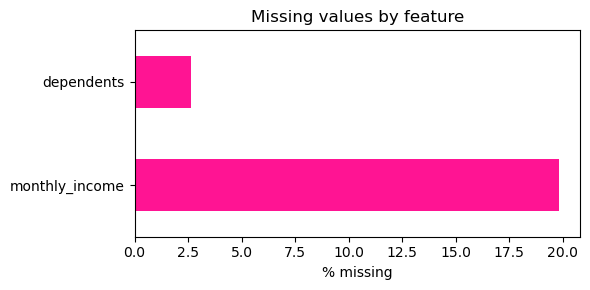

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
(missing_val * 100).plot.barh(ax=ax, color="deeppink")
ax.set_xlabel("% missing")
ax.set_title("Missing values by feature")
plt.tight_layout()
plt.show()

In [5]:
#class imbalance
class_balance = df["default"].value_counts(normalize=True).sort_index()
class_balance

default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

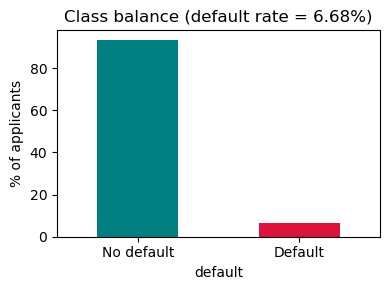

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))
class_balance.rename({0: "No default", 1: "Default"}).mul(100).plot.bar(
    ax=ax, color=["teal", "crimson"]
)
ax.set_ylabel("% of applicants")
ax.set_title(f"Class balance (default rate = {class_balance[1]:.2%})")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [7]:
#outliers->age, late_cols, debt_ratio and revolving utilization
print("Rows with age = 0:", (df["age"] == 0).sum())

late_cols = ["late_30_59", "late_60_89", "late_90_plus"]
for c in late_cols:
    print(f"{c}: rows with sentinel value 96/98 ->", df[c].isin([96, 98]).sum())

print("Rows with debt_ratio > 1:", (df["debt_ratio"] > 1).sum())
print("Rows with revolving_utilization > 1:", (df["revolving_utilization"] > 1).sum())

Rows with age = 0: 1
late_30_59: rows with sentinel value 96/98 -> 269
late_60_89: rows with sentinel value 96/98 -> 269
late_90_plus: rows with sentinel value 96/98 -> 269
Rows with debt_ratio > 1: 35137
Rows with revolving_utilization > 1: 3321


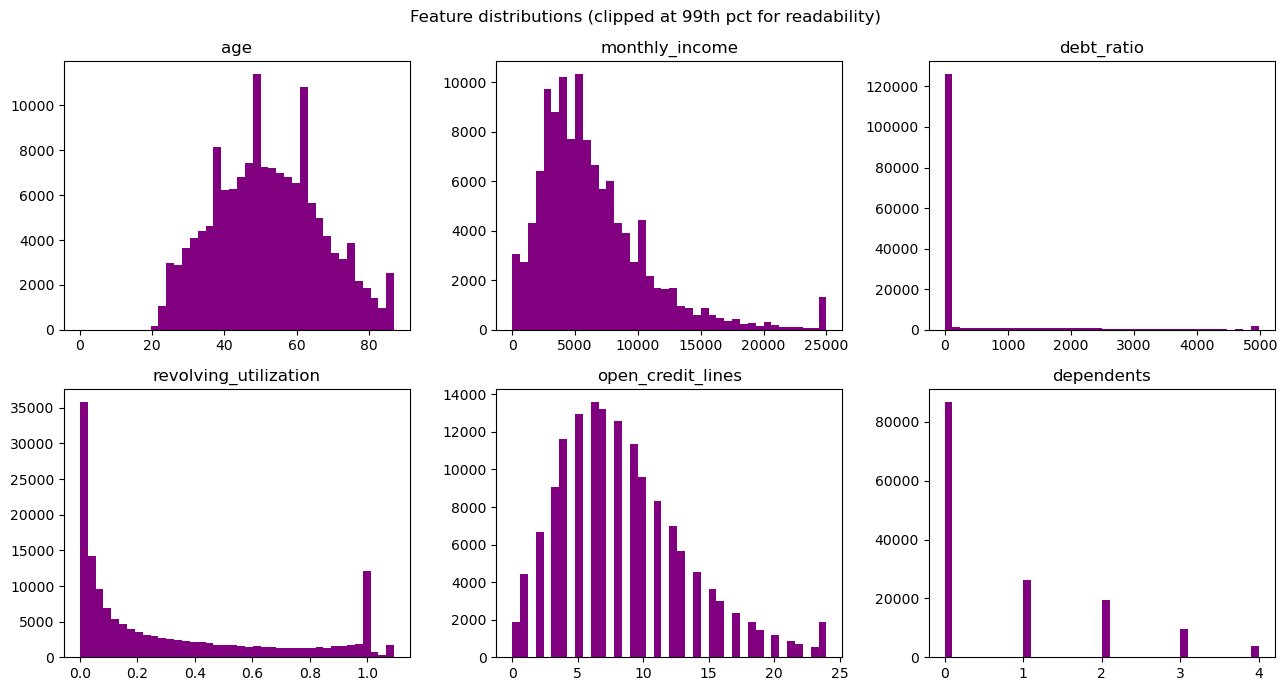

In [8]:
#distributions
cols = ["age", "monthly_income", "debt_ratio", "revolving_utilization", "open_credit_lines", "dependents"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, cols):
    data = df[col].dropna()
    upper = data.quantile(0.99)
    ax.hist(data.clip(upper=upper), bins=40, color="purple")
    ax.set_title(col)
fig.suptitle("Feature distributions (clipped at 99th pct for readability)")
plt.tight_layout()
plt.show()

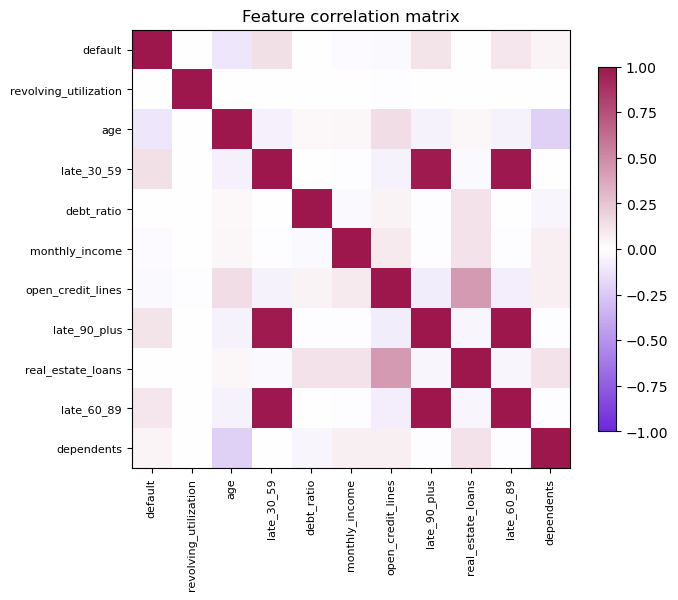

In [9]:
#correlations
from matplotlib.colors import LinearSegmentedColormap

pink_violet = LinearSegmentedColormap.from_list(
    "pink_violet", ["#6d28d9", "#ffffff", "#9d174d"]
)

corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap=pink_violet, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [10]:
d = df.copy()
d["debt_ratio_bucket"] = pd.qcut(
    d["debt_ratio"].clip(upper=d["debt_ratio"].quantile(0.99)),
    5, duplicates="drop"
)
d.groupby("debt_ratio_bucket", observed=True)["default"].mean().mul(100).round(2)

debt_ratio_bucket
(-0.001, 0.134]    6.10
(0.134, 0.287]     5.72
(0.287, 0.468]     6.18
(0.468, 4.0]       9.88
(4.0, 4979.04]     5.53
Name: default, dtype: float64

In [11]:
d2 = df.dropna(subset=["monthly_income"]).copy()
d2["income_bucket"] = pd.qcut(
    d2["monthly_income"].clip(upper=d2["monthly_income"].quantile(0.99)),
    5, duplicates="drop"
)
d2.groupby("income_bucket", observed=True)["default"].mean().mul(100).round(2)

income_bucket
(-0.001, 3000.0]     9.08
(3000.0, 4544.2]     8.60
(4544.2, 6300.0]     7.01
(6300.0, 9083.0]     5.53
(9083.0, 25000.0]    4.50
Name: default, dtype: float64

In [12]:
d3 = df[~df[["late_30_59", "late_60_89", "late_90_plus"]].isin([96, 98]).any(axis=1)].copy()
d3["had_late_payment"] = (d3[["late_30_59", "late_60_89", "late_90_plus"]].sum(axis=1) > 0)
d3.groupby("had_late_payment")["default"].mean().mul(100).round(2)

had_late_payment
False     2.73
True     21.98
Name: default, dtype: float64

In [13]:
d4 = df[df["age"] > 0].copy()
d4["age_bucket"] = pd.cut(d4["age"], bins=[17, 30, 40, 50, 60, 70, 110])
d4.groupby("age_bucket", observed=True)["default"].mean().mul(100).round(2)

age_bucket
(17, 30]     11.56
(30, 40]      9.82
(40, 50]      8.26
(50, 60]      6.17
(60, 70]      3.47
(70, 110]     2.26
Name: default, dtype: float64

In [14]:
d5 = df.copy()
d5["utilization_bucket"] = pd.qcut(
    d5["revolving_utilization"].clip(upper=d5["revolving_utilization"].quantile(0.99)),
    5, duplicates="drop"
)
d5.groupby("utilization_bucket", observed=True)["default"].mean().mul(100).round(2)

utilization_bucket
(-0.001, 0.0192]     1.94
(0.0192, 0.0832]     1.66
(0.0832, 0.271]      2.92
(0.271, 0.699]       7.02
(0.699, 1.093]      19.88
Name: default, dtype: float64

In [15]:
import seaborn as sns
sns.__version__

'0.13.2'

C:\Users\flish\AppData\Local\Temp\ipykernel_48500\2008409290.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(b) for b in rate[bucket_col]], rotation=45, ha="right", fontsize=7)
C:\Users\flish\AppData\Local\Temp\ipykernel_48500\2008409290.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(b) for b in rate[bucket_col]], rotation=45, ha="right", fontsize=7)
C:\Users\flish\AppData\Local\Temp\ipykernel_48500\2008409290.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(b) for b in rate[bucket_col]], rotation=45, ha="right", fontsize=7)
C:\Users\flish\AppData\Local\Temp\ipykernel_48500\2008409290.py:7: UserWarning: set_ticklabels() should only be used with a fixed num

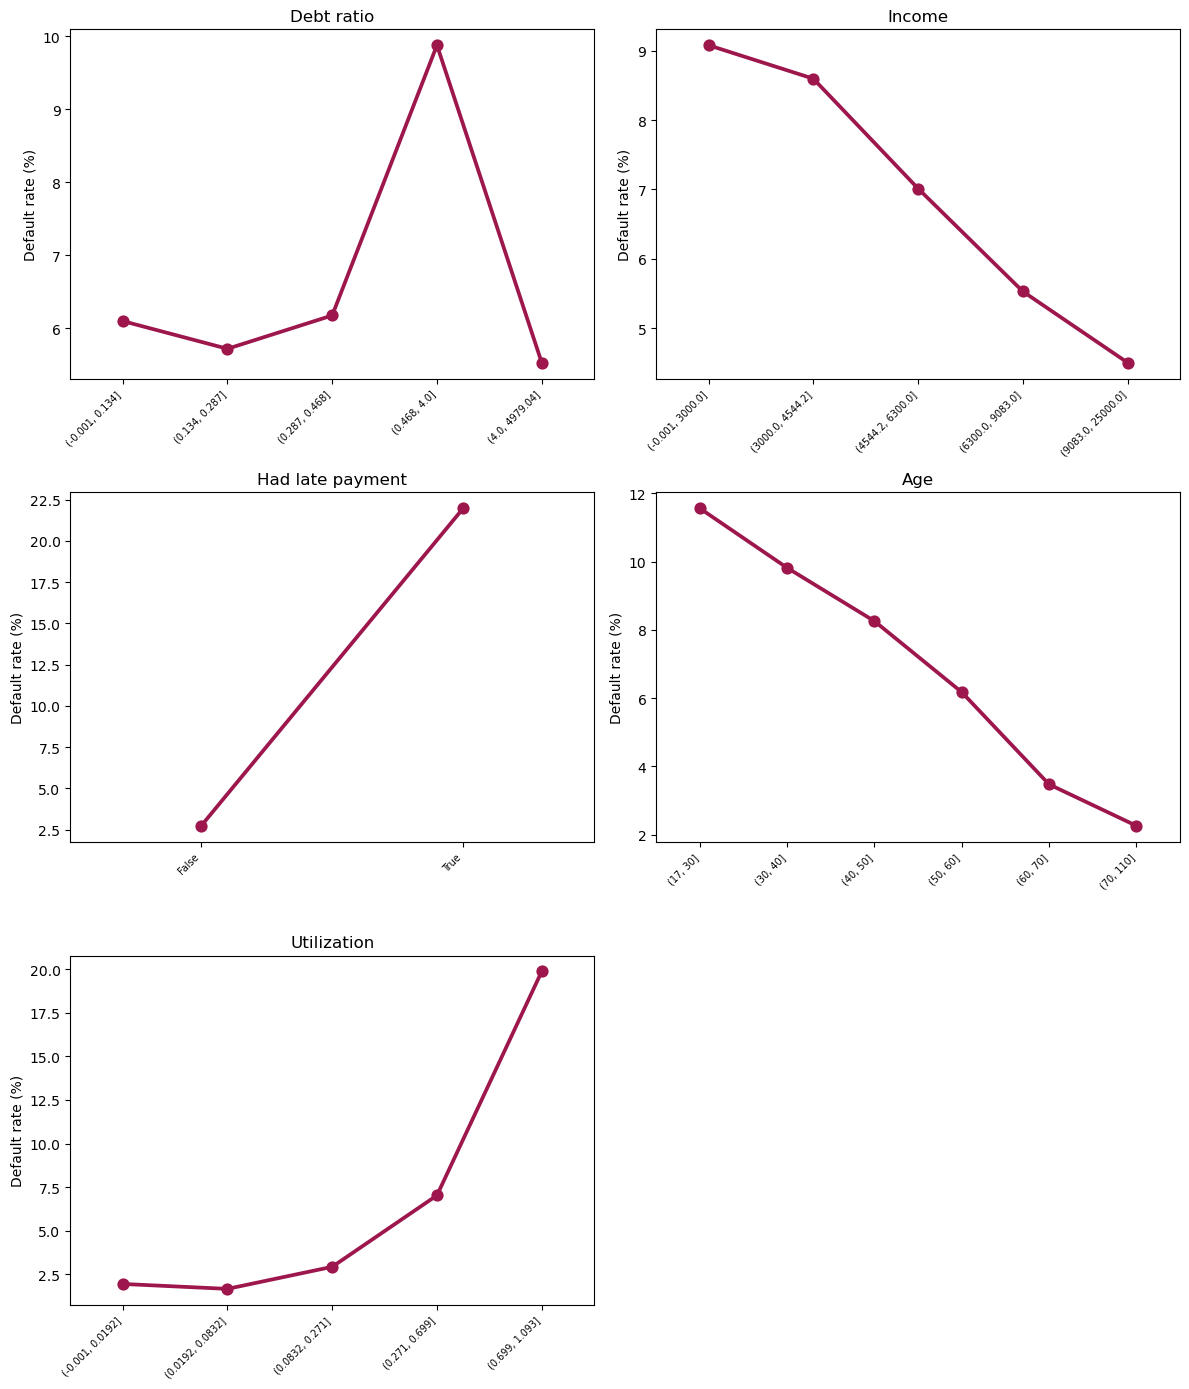

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flat  # flattens the 3x2 grid into a simple list of 6, so we can index axes[0]..axes[5]

def plot_bucket(ax, data, bucket_col, title, color="#9d174d"):
    rate = data.groupby(bucket_col, observed=True)["default"].mean().mul(100).reset_index()
    sns.pointplot(data=rate, x=bucket_col, y="default", ax=ax, color=color)
    ax.set_xticklabels([str(b) for b in rate[bucket_col]], rotation=45, ha="right", fontsize=7)
    ax.set_title(title)
    ax.set_ylabel("Default rate (%)")
    ax.set_xlabel("")

d1 = df.copy()
d1["b"] = pd.qcut(d1["debt_ratio"].clip(upper=d1["debt_ratio"].quantile(0.99)), 5, duplicates="drop")
plot_bucket(axes[0], d1, "b", "Debt ratio")

d2 = df.dropna(subset=["monthly_income"]).copy()
d2["b"] = pd.qcut(d2["monthly_income"].clip(upper=d2["monthly_income"].quantile(0.99)), 5, duplicates="drop")
plot_bucket(axes[1], d2, "b", "Income")

d3 = df[~df[["late_30_59", "late_60_89", "late_90_plus"]].isin([96, 98]).any(axis=1)].copy()
d3["b"] = (d3[["late_30_59", "late_60_89", "late_90_plus"]].sum(axis=1) > 0)
plot_bucket(axes[2], d3, "b", "Had late payment")

d4 = df[df["age"] > 0].copy()
d4["b"] = pd.cut(d4["age"], bins=[17, 30, 40, 50, 60, 70, 110])
plot_bucket(axes[3], d4, "b", "Age")

d5 = df.copy()
d5["b"] = pd.qcut(d5["revolving_utilization"].clip(upper=d5["revolving_utilization"].quantile(0.99)), 5, duplicates="drop")
plot_bucket(axes[4], d5, "b", "Utilization")

axes[5].axis("off")  # hide the 6th, unused slot

plt.tight_layout()
plt.show()

In [17]:
df_fe = df.copy()

for col in ["late_30_59", "late_60_89", "late_90_plus"]:
    df_fe[col] = df_fe[col].replace([96, 98], np.nan)

In [18]:
for col in ["late_30_59", "late_60_89", "late_90_plus"]:
    median_val = df_fe[col].median()
    print(col, "median:", median_val)
    df_fe[col] = df_fe[col].fillna(median_val)

late_30_59 median: 0.0
late_60_89 median: 0.0
late_90_plus median: 0.0


In [19]:
df_fe["TOTAL_DELINQUENCY"] = df_fe["late_30_59"] + df_fe["late_60_89"] + df_fe["late_90_plus"]
df_fe["HAS_PREVIOUS_DELINQUENCY"] = (df_fe["TOTAL_DELINQUENCY"] > 0).astype(int)

df_fe[["late_30_59", "late_60_89", "late_90_plus", "TOTAL_DELINQUENCY", "HAS_PREVIOUS_DELINQUENCY"]].head()

,late_30_59,late_60_89,late_90_plus,TOTAL_DELINQUENCY,HAS_PREVIOUS_DELINQUENCY
1,2.0,0.0,0.0,2.0,1
2,0.0,0.0,0.0,0.0,0
3,1.0,0.0,1.0,2.0,1
4,0.0,0.0,0.0,0.0,0
5,1.0,0.0,0.0,1.0,1


In [20]:
def utilization_level(u):
    if u < 0.3:
        return "Low"
    elif u < 0.7:
        return "Medium"
    else:
        return "High"

df_fe["CREDIT_UTILIZATION_LEVEL"] = df_fe["revolving_utilization"].apply(utilization_level)

df_fe["CREDIT_UTILIZATION_LEVEL"].value_counts()

CREDIT_UTILIZATION_LEVEL
Low       92882
High      29948
Medium    27170
Name: count, dtype: int64

In [21]:
df_fe["HIGH_DEBT_RATIO"] = (df_fe["debt_ratio"] > 0.468).astype(int)

df_fe["HIGH_DEBT_RATIO"].value_counts()

HIGH_DEBT_RATIO
0    90060
1    59940
Name: count, dtype: int64

In [22]:
df_fe["INCOME_PER_DEPENDENT"] = df_fe["monthly_income"] / (df_fe["dependents"].fillna(0) + 1)

df_fe[["monthly_income", "dependents", "INCOME_PER_DEPENDENT"]].head()

,monthly_income,dependents,INCOME_PER_DEPENDENT
1,9120.0,2.0,3040.0
2,2600.0,1.0,1300.0
3,3042.0,0.0,3042.0
4,3300.0,0.0,3300.0
5,63588.0,0.0,63588.0


In [23]:
df_fe["HAS_MISSING_INCOME"] = df_fe["monthly_income"].isna().astype(int)

income_median = df_fe["monthly_income"].median()
print("Income median:", income_median)
df_fe["monthly_income"] = df_fe["monthly_income"].fillna(income_median)

df_fe["INCOME_PER_DEPENDENT"] = df_fe["monthly_income"] / (df_fe["dependents"].fillna(0) + 1)

Income median: 5400.0


In [24]:
df_fe["dependents"] = df_fe["dependents"].fillna(0)

df_fe.isna().sum()

default                     0
revolving_utilization       0
age                         0
late_30_59                  0
debt_ratio                  0
monthly_income              0
open_credit_lines           0
late_90_plus                0
real_estate_loans           0
late_60_89                  0
dependents                  0
TOTAL_DELINQUENCY           0
HAS_PREVIOUS_DELINQUENCY    0
CREDIT_UTILIZATION_LEVEL    0
HIGH_DEBT_RATIO             0
INCOME_PER_DEPENDENT        0
HAS_MISSING_INCOME          0
dtype: int64

In [25]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [26]:
# training models 


encoder = OneHotEncoder(drop="first", sparse_output=False).set_output(transform="pandas")
encoded_df = encoder.fit_transform(df_fe[["CREDIT_UTILIZATION_LEVEL"]])

df_enc = df_fe.drop(columns=["CREDIT_UTILIZATION_LEVEL"])
df_enc[encoded_df.columns] = encoded_df

X=df_enc.drop(columns=["default"])
y=df_enc["default"]

In [27]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [28]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [29]:
log_reg=LogisticRegression(class_weight="balanced",random_state=42)
log_reg.fit(X_train_scaled,y_train)
lr_pred=log_reg.predict(X_test_scaled)

print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27995
           1       0.21      0.75      0.33      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.84     30000



In [30]:
dtree=DecisionTreeClassifier(class_weight="balanced",random_state=42)
dtree.fit(X_train,y_train)

dt_pred=dtree.predict(X_test)
print(classification_report(y_test,dt_pred))
dtt_pred=dtree.predict(X_train)
print(classification_report(y_train,dtt_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     27995
           1       0.26      0.25      0.26      2005

    accuracy                           0.90     30000
   macro avg       0.60      0.60      0.60     30000
weighted avg       0.90      0.90      0.90     30000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    111979
           1       0.98      1.00      0.99      8021

    accuracy                           1.00    120000
   macro avg       0.99      1.00      1.00    120000
weighted avg       1.00      1.00      1.00    120000



In [31]:
rf=RandomForestClassifier(class_weight="balanced")
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
rff_pred=rf.predict(X_train)
print(classification_report(y_test,rf_pred))
print(classification_report(y_train,rff_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.52      0.15      0.23      2005

    accuracy                           0.93     30000
   macro avg       0.73      0.57      0.60     30000
weighted avg       0.91      0.93      0.92     30000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    111979
           1       0.98      1.00      0.99      8021

    accuracy                           1.00    120000
   macro avg       0.99      1.00      1.00    120000
weighted avg       1.00      1.00      1.00    120000



In [32]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred=xgb.predict(X_test)
xgbb_pred=xgb.predict(X_train)
print(classification_report(y_test,xgb_pred))
print(classification_report(y_train, xgbb_pred))

scale_pos_weight: 13.960728088766986
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27995
           1       0.23      0.70      0.35      2005

    accuracy                           0.82     30000
   macro avg       0.60      0.77      0.62     30000
weighted avg       0.93      0.82      0.86     30000

              precision    recall  f1-score   support

           0       0.99      0.84      0.91    111979
           1       0.29      0.87      0.43      8021

    accuracy                           0.85    120000
   macro avg       0.64      0.86      0.67    120000
weighted avg       0.94      0.85      0.88    120000



In [33]:
lgbm = LGBMClassifier(class_weight="balanced", random_state=42)
lgbm.fit(X_train, y_train)

lgbm_pred=lgbm.predict(X_test)
lgbmm_pred=lgbm.predict(X_train)

print(classification_report(y_test,lgbm_pred))
print(classification_report(y_train, lgbmm_pred))


[LightGBM] [Info] Number of positive: 8021, number of negative: 111979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1256
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     27995
           1       0.22      0.77      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000

              precision    recall  f1-score   support

           0       0.98      0.81      0.89    111979
     

In [34]:
models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Decision Tree": (dtree, X_test),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test),
    "LightGBM": (lgbm, X_test),
}

for name, (model, X_eval) in models.items():
    proba = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"{name}: ROC-AUC = {auc:.4f}")

Logistic Regression: ROC-AUC = 0.8573
Decision Tree: ROC-AUC = 0.6009
Random Forest: ROC-AUC = 0.8351
XGBoost: ROC-AUC = 0.8484
LightGBM: ROC-AUC = 0.8666


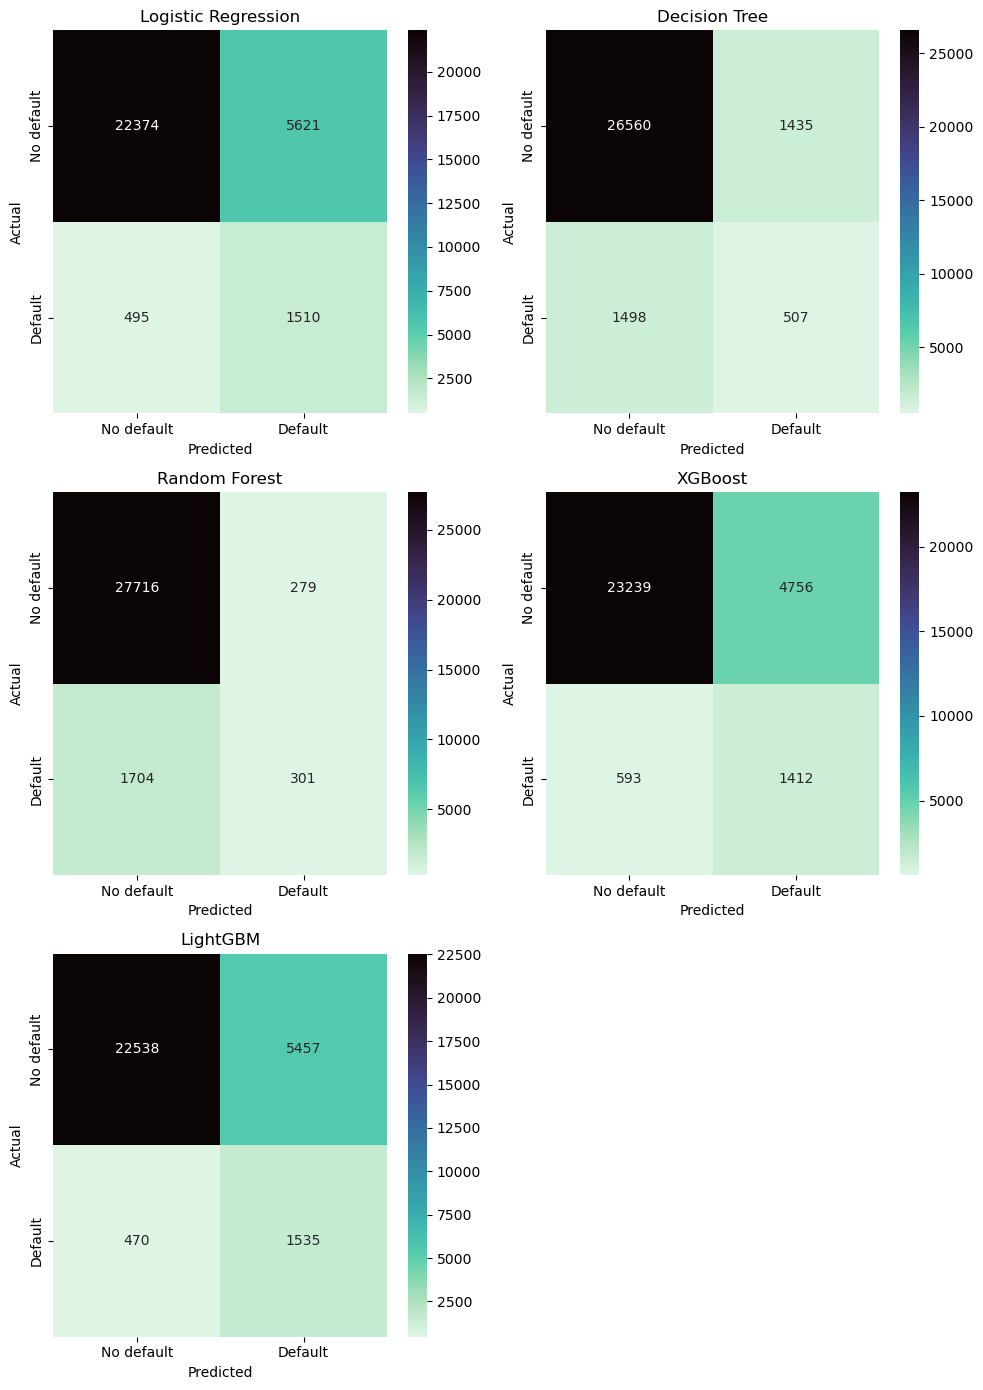

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(10, 14))
axes = axes.flat
model_preds = {
    "Logistic Regression": (y_test, lr_pred),
    "Decision Tree": (y_test, dt_pred),
    "Random Forest": (y_test, rf_pred),
    "XGBoost": (y_test,xgb_pred),
    "LightGBM": (y_test, lgbm_pred),
}

for ax, (name, (y_true, y_pred)) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="mako_r", ax=ax,
                xticklabels=["No default", "Default"], yticklabels=["No default", "Default"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[5].axis("off")
plt.tight_layout()
plt.show()

In [36]:
coefficients = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
coefficients

CREDIT_UTILIZATION_LEVEL_Low      -0.835109
HAS_PREVIOUS_DELINQUENCY           0.418690
CREDIT_UTILIZATION_LEVEL_Medium   -0.322942
age                               -0.303197
late_90_plus                       0.247359
monthly_income                    -0.235887
TOTAL_DELINQUENCY                  0.169605
late_60_89                         0.146544
debt_ratio                        -0.119201
HIGH_DEBT_RATIO                    0.118143
real_estate_loans                  0.113658
open_credit_lines                  0.111250
INCOME_PER_DEPENDENT               0.084250
HAS_MISSING_INCOME                -0.061542
revolving_utilization             -0.041322
late_30_59                         0.027214
dependents                         0.025685
dtype: float64

In [37]:
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
lgbm_gain = pd.Series(lgbm.booster_.feature_importance(importance_type="gain"), index=X.columns).sort_values(ascending=False)

print("XGBoost:")
print(xgb_importance)
print("\nLightGBM:")
print(lgbm_gain)

XGBoost:
TOTAL_DELINQUENCY                  0.601220
revolving_utilization              0.069619
HAS_MISSING_INCOME                 0.042388
real_estate_loans                  0.034473
late_90_plus                       0.029462
open_credit_lines                  0.023579
late_30_59                         0.023266
age                                0.022449
debt_ratio                         0.022161
monthly_income                     0.020837
INCOME_PER_DEPENDENT               0.020812
HIGH_DEBT_RATIO                    0.020485
CREDIT_UTILIZATION_LEVEL_Low       0.019175
late_60_89                         0.016919
CREDIT_UTILIZATION_LEVEL_Medium    0.016850
dependents                         0.016306
HAS_PREVIOUS_DELINQUENCY           0.000000
dtype: float32

LightGBM:
TOTAL_DELINQUENCY                  186550.208310
revolving_utilization               83834.471140
debt_ratio                          17773.713994
age                                 16111.224022
open_credit_lines    

In [38]:
dtree_importance = pd.Series(dtree.feature_importances_, index=X.columns).sort_values(ascending=False)
forest_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Decision Tree:")
print(dtree_importance)
print("\nRandom Forest:")
print(forest_importance)

Decision Tree:
HAS_PREVIOUS_DELINQUENCY           0.248491
revolving_utilization              0.208603
debt_ratio                         0.140574
age                                0.099352
INCOME_PER_DEPENDENT               0.086067
monthly_income                     0.081174
open_credit_lines                  0.064230
real_estate_loans                  0.023846
TOTAL_DELINQUENCY                  0.016151
dependents                         0.013471
late_30_59                         0.006786
late_90_plus                       0.004386
late_60_89                         0.002854
HIGH_DEBT_RATIO                    0.001704
CREDIT_UTILIZATION_LEVEL_Medium    0.001136
HAS_MISSING_INCOME                 0.001067
CREDIT_UTILIZATION_LEVEL_Low       0.000109
dtype: float64

Random Forest:
revolving_utilization              0.168894
debt_ratio                         0.116544
age                                0.100619
HAS_PREVIOUS_DELINQUENCY           0.095200
INCOME_PER_DEPENDENT          

In [40]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(shap_values.shape)

print(explainer.expected_value)

<class 'numpy.ndarray'>
(30000, 17)
-0.014006991


In [41]:
row = 0
print(X_test.iloc[row])
print(shap_values[row])

revolving_utilization                 0.019252
age                                  66.000000
late_30_59                            0.000000
debt_ratio                            0.433926
monthly_income                     5175.000000
open_credit_lines                    13.000000
late_90_plus                          0.000000
real_estate_loans                     1.000000
late_60_89                            0.000000
dependents                            0.000000
TOTAL_DELINQUENCY                     0.000000
HAS_PREVIOUS_DELINQUENCY              0.000000
HIGH_DEBT_RATIO                       0.000000
INCOME_PER_DEPENDENT               5175.000000
HAS_MISSING_INCOME                    0.000000
CREDIT_UTILIZATION_LEVEL_Low          1.000000
CREDIT_UTILIZATION_LEVEL_Medium       0.000000
Name: 10683, dtype: float64
[-1.3055159  -0.63969207  0.01432596  0.20407508 -0.2519015  -0.20280778
 -0.09618942 -0.20229568 -0.04756582 -0.0013411  -0.9978553   0.
 -0.04542075  0.1446568   0.0225811

In [42]:
import numpy as np

margin = explainer.expected_value + shap_values[row].sum()
probability = 1 / (1 + np.exp(-margin))

print("SHAP-reconstructed probability:", probability)
print("Model's actual probability:", xgb.predict_proba(X_test.iloc[[row]])[:, 1])

SHAP-reconstructed probability: 0.0320666051415755
Model's actual probability: [0.03206661]


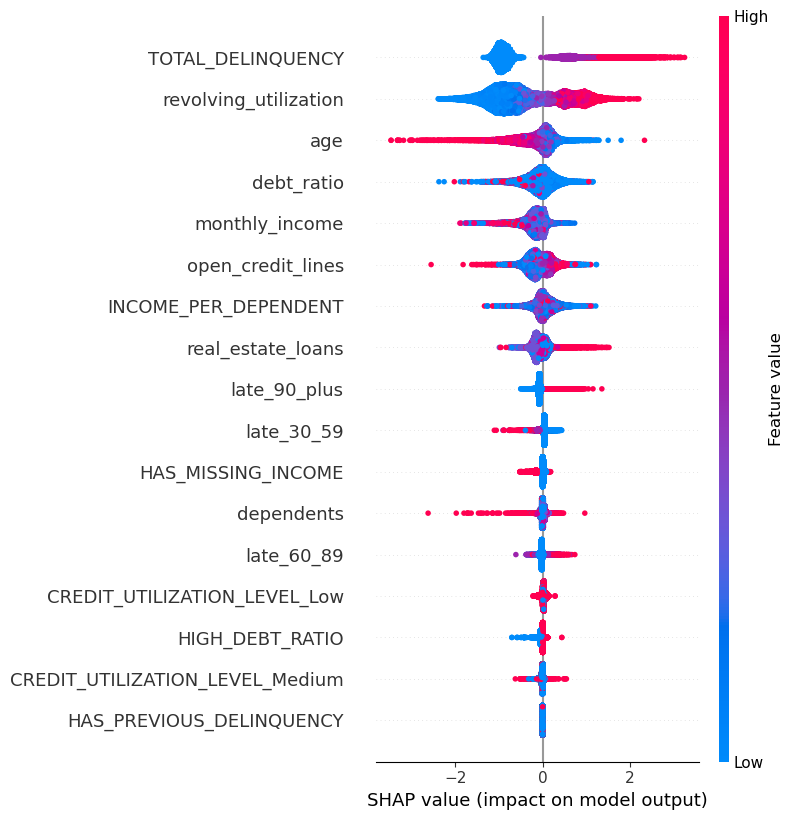

In [43]:
shap.summary_plot(shap_values, X_test)

In [44]:
sample = X_test.iloc[[5]]
prob = xgb.predict_proba(sample)[:, 1]
print(prob)

[0.02210807]


In [45]:
def risk_label(probability):
    if probability < 0.10:
        return "Low"
    elif probability < 0.30:
        return "Medium"
    else:
        return "High"

print(risk_label(prob[0]))

Low


In [46]:
result = {
    "probabilityOfDefault": round(float(prob[0]), 4),
    "riskPrediction": risk_label(prob[0]),
    "model": "XGBoost",
    "modelVersion": "1.0"
}

print(result)

{'probabilityOfDefault': 0.0221, 'riskPrediction': 'Low', 'model': 'XGBoost', 'modelVersion': '1.0'}


In [53]:
import joblib

joblib.dump(xgb, "../models/xgb_credit_risk.pkl")

['../models/xgb_credit_risk.pkl']

In [54]:
import pandas as pd

LATE_MEDIAN = 0.0
INCOME_MEDIAN = 5400.0

FEATURE_ORDER = [
    "revolving_utilization", "age", "late_30_59", "debt_ratio", "monthly_income",
    "open_credit_lines", "late_90_plus", "real_estate_loans", "late_60_89", "dependents",
    "TOTAL_DELINQUENCY", "HAS_PREVIOUS_DELINQUENCY", "HIGH_DEBT_RATIO",
    "INCOME_PER_DEPENDENT", "HAS_MISSING_INCOME",
    "CREDIT_UTILIZATION_LEVEL_Low", "CREDIT_UTILIZATION_LEVEL_Medium",
]

def engineer_features(raw: dict) -> pd.DataFrame:
    row = dict(raw)  # copy so we don't mutate the caller's dict

    for col in ["late_30_59", "late_60_89", "late_90_plus"]:
        if row[col] in (96, 98):
            row[col] = LATE_MEDIAN

    row["TOTAL_DELINQUENCY"] = row["late_30_59"] + row["late_60_89"] + row["late_90_plus"]
    row["HAS_PREVIOUS_DELINQUENCY"] = int(row["TOTAL_DELINQUENCY"] > 0)

    u = row["revolving_utilization"]
    level = "Low" if u < 0.3 else ("Medium" if u < 0.7 else "High")
    row["CREDIT_UTILIZATION_LEVEL_Low"] = int(level == "Low")
    row["CREDIT_UTILIZATION_LEVEL_Medium"] = int(level == "Medium")

    row["HIGH_DEBT_RATIO"] = int(row["debt_ratio"] > 0.468)

    row["HAS_MISSING_INCOME"] = int(row["monthly_income"] is None)
    if row["monthly_income"] is None:
        row["monthly_income"] = INCOME_MEDIAN

    row["dependents"] = row["dependents"] or 0
    row["INCOME_PER_DEPENDENT"] = row["monthly_income"] / (row["dependents"] + 1)

    return pd.DataFrame([row])[FEATURE_ORDER]

In [55]:
test_raw = {
    "revolving_utilization": 0.019252, "age": 66, "late_30_59": 0, "debt_ratio": 0.433926,
    "monthly_income": 5175.0, "open_credit_lines": 13, "late_90_plus": 0,
    "real_estate_loans": 1, "late_60_89": 0, "dependents": 0
}

engineer_features(test_raw)

,revolving_utilization,age,late_30_59,debt_ratio,monthly_income,open_credit_lines,late_90_plus,real_estate_loans,late_60_89,dependents,TOTAL_DELINQUENCY,HAS_PREVIOUS_DELINQUENCY,HIGH_DEBT_RATIO,INCOME_PER_DEPENDENT,HAS_MISSING_INCOME,CREDIT_UTILIZATION_LEVEL_Low,CREDIT_UTILIZATION_LEVEL_Medium
0,0.019252,66,0,0.433926,5175.0,13,0,1,0,0,0,0,0,5175.0,0,1,0


In [56]:
features = engineer_features(test_raw)
prob = xgb.predict_proba(features)[:, 1]
print(prob)

[0.03206661]


In [58]:
import fastapi, uvicorn
print(fastapi.__version__, uvicorn.__version__)

0.141.1 0.52.4
